# tr_diffusion — reconstruction test of the baseline denoiser

End-to-end downstream test: reconstruct the rotating `212_Wunderkerze2` sample from its
projection stream and measure how close the **denoised** reconstruction is to the **GT
(native, low-noise)** reconstruction, versus the **un-denoised noisy floor**.

Setup: dose-0.05 input (5% photons → 20× dose reduction), baseline denoiser
(`tr_denoise_baseline_k1_dose005`), counts→attenuation (`p=-ln(count/I0)`), parallel-beam
sliding-window reconstruction (window = 180° ≈ 100 frames, disjoint stride, `det_bin=2` →
256² volumes), FBP over all 996 windows + iterative GD on the most-dynamic window.
Results cached in `tr_recon_cache/` by `scripts/tr_diffusion_reconstruct_run.py`.

In [ ]:
%matplotlib inline
import sys, json, numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0,'/myhome/sdate'); sys.path.insert(0,'/myhome/astra-torch')
import sdate.tr_diffusion.reconstruct as R
from sdate.tr_diffusion.frames import MemmapFrameSource
from sdate.tr_diffusion.profiles import DatasetProfile

# --- Change these to point the whole notebook at a different acquisition/run. ---
PROFILE = 'wunderkerze2'   # or 'asc_thixo', or a profile JSON path
TAG = ''                   # '' -> untagged default run; else matches --tag used when reconstructing
prof = DatasetProfile.load(PROFILE) 
PERIOD_360 = prof.period_360

CACHE = '/myhome/data/sdate/shared/time_resolved/tr_recon_cache'
_suf = f'_{TAG}' if TAG else ''
summary = json.load(open(f'{CACHE}/recon_summary{_suf}.json')); d = np.load(f'{CACHE}/recon_results{_suf}.npz')
print(json.dumps(summary, indent=2))

{
  "n_windows": 996,
  "det_bin": 2,
  "window_deg": 180.0,
  "fbp_denoised_psnr": 35.179151060112034,
  "fbp_denoised_ssim": 0.9017697511001147,
  "fbp_noisy_psnr": 24.559718578216064,
  "fbp_noisy_ssim": 0.376968072984265,
  "gd_denoised_psnr": 29.05706548690796,
  "gd_noisy_psnr": 14.936760425567627,
  "dyn_start": 400300,
  "gd_starts": [
    400200,
    400300,
    400400,
    400500
  ],
  "minutes": 13.9
}


## 1. Reconstruction quality across the full sequence (996 windows)

denoised  PSNR 35.18 dB (min 27.7, max 41.5) | SSIM 0.902
noisy     PSNR 24.56 dB (min 18.0, max 31.6) | SSIM 0.377
GAIN from denoising: +10.62 dB / +0.525 SSIM


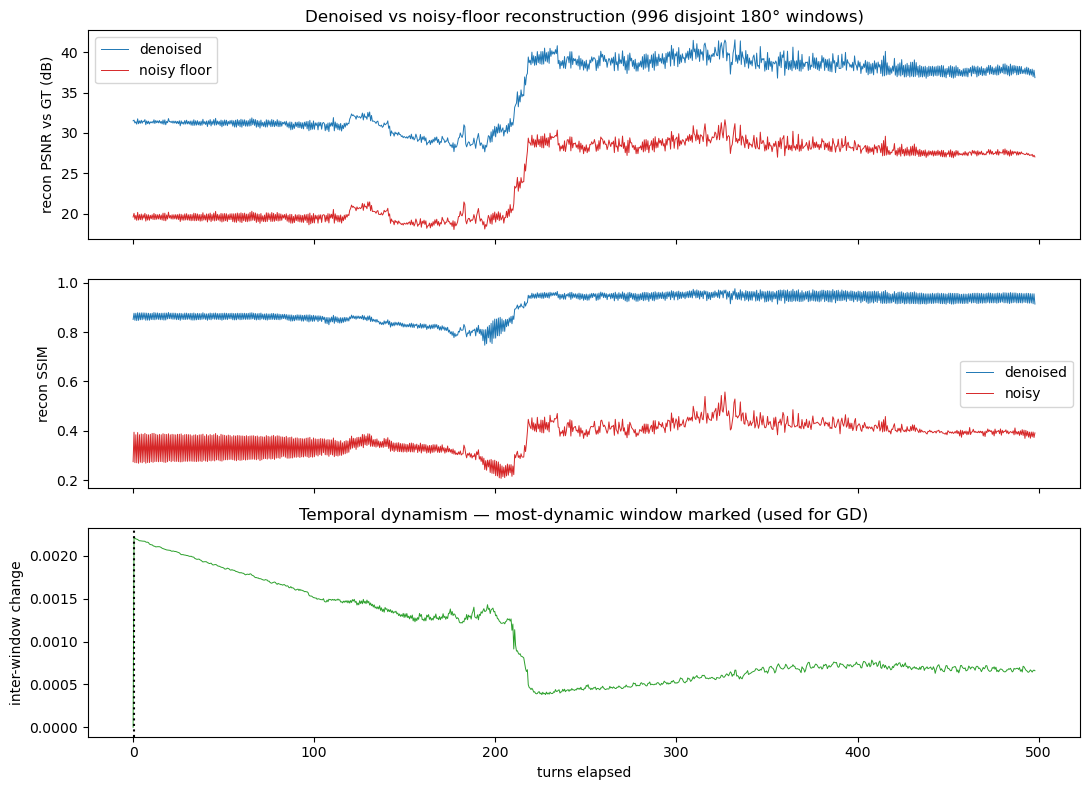

In [2]:
ws=d['window_starts']; dp=d['den_psnr']; npr=d['noisy_psnr']; ds=d['den_ssim']; ns=d['noisy_ssim']; ch=d['change']
turns=(ws-ws[0])/PERIOD_360
print(f"denoised  PSNR {dp.mean():.2f} dB (min {dp.min():.1f}, max {dp.max():.1f}) | SSIM {ds.mean():.3f}")
print(f"noisy     PSNR {npr.mean():.2f} dB (min {npr.min():.1f}, max {npr.max():.1f}) | SSIM {ns.mean():.3f}")
print(f"GAIN from denoising: +{dp.mean()-npr.mean():.2f} dB / +{ds.mean()-ns.mean():.3f} SSIM")

fig,ax=plt.subplots(3,1,figsize=(11,8),sharex=True)
ax[0].plot(turns,dp,lw=0.7,label='denoised'); ax[0].plot(turns,npr,lw=0.7,color='C3',label='noisy floor')
ax[0].set_ylabel('recon PSNR vs GT (dB)'); ax[0].legend(); ax[0].set_title('Denoised vs noisy-floor reconstruction (996 disjoint 180° windows)')
ax[1].plot(turns,ds,lw=0.7,label='denoised'); ax[1].plot(turns,ns,lw=0.7,color='C3',label='noisy'); ax[1].set_ylabel('recon SSIM'); ax[1].legend()
ax[2].plot(turns,ch,lw=0.7,color='C2'); ax[2].axvline(turns[int(ch.argmax())],ls=':',color='k')
ax[2].set_ylabel('inter-window change'); ax[2].set_xlabel('turns elapsed'); ax[2].set_title('Temporal dynamism — most-dynamic window marked (used for GD)')
plt.tight_layout(); plt.show()

The sample is highly dynamic for the first ~210 turns, then the reaction settles (both PSNRs
jump as the static object reconstructs better). The denoiser holds a **consistent ~+10.6 dB /
+0.53 SSIM** gain throughout — the low-dose reconstruction is only usable *with* denoising.

## 2. Visual comparison — dynamic vs settled phase

/myhome/sdate/sdate/tr_diffusion/reconstruct.py:220: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  x = torch.from_numpy(raw).to(device).float()


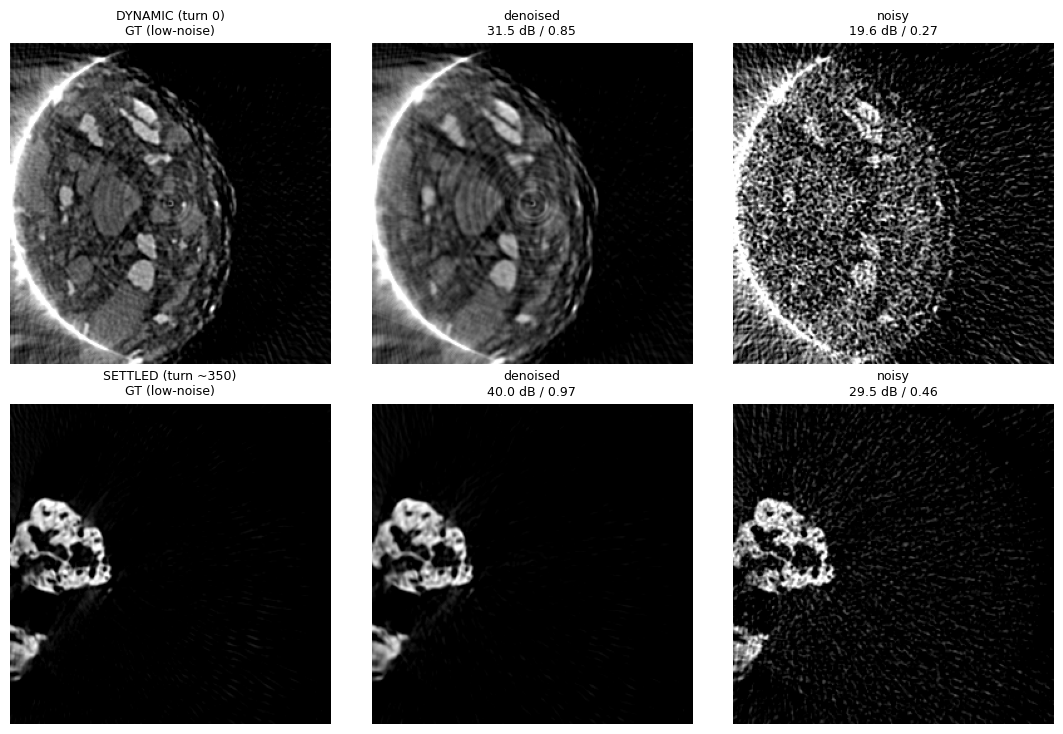

In [3]:
dcap = prof.mov_path.rsplit('/', 1)[0]
den_path = f'{dcap}/denoised_baseline_dose005.f16'   # produced by tr_diffusion_reconstruct_run.py / denoise_sequence
meta = np.load(den_path + '.meta.npz')
first=int(meta['first_index']); n=int(meta['num_frames']); crop=tuple(meta['crop']); dose=float(meta['dose']); seed=int(meta['noise_seed'])
den_mm=np.memmap(den_path,dtype=np.float16,mode='r',shape=(n,crop[0],crop[1]))
src=MemmapFrameSource(prof.memmap_path, prof.mov_path)
dev=torch.device('cuda'); I0=R.estimate_I0(src,np.arange(first,first+n,1500),crop)
win=R.window_length_frames(180.0, prof.deg_per_frame)
H=crop[1]//2; mask=R.make_mask(H,H).to(dev)
def arms(s):
    idx=np.arange(s,s+win); gt=R.native_window_gpu(src,idx,crop,prof.rot_axis_col,dev)
    g=torch.Generator(device=dev).manual_seed(seed+s)
    cs={'GT':gt,'noisy':R.noisy_window_gpu(gt,dose,g),'denoised':R.denoised_window_gpu(den_mm,first,idx,dev)}
    return {a:R.reconstruct(R.counts_to_attenuation(cs[a],I0),R.projection_angles(idx,deg_per_frame=prof.deg_per_frame),det_bin=2,method='fbp',device=dev) for a in R.ARMS}
fig,ax=plt.subplots(2,3,figsize=(11,7.4))
for r,(lbl,s) in enumerate([('EARLY (turn 0)',first),('LATER (turn ~350)',first+350*win)]):
    v=arms(s); z=v['GT'].shape[0]//2; dr=float(v['GT'][...,mask].max()-v['GT'][...,mask].min())
    for c,a in enumerate(R.ARMS):
        ax[r,c].imshow(v[a][z].cpu().numpy(),cmap='gray',vmin=0,vmax=0.02); ax[r,c].axis('off')
        t=f'{lbl}\nGT (low-noise)' if a=='GT' else f'{a}\n%.1f dB / %.2f'%R.masked_scores(v['GT'],v[a],mask,dr)
        ax[r,c].set_title(t,fontsize=9)
plt.tight_layout(); plt.show()

## 3. Movies (slice through the reconstructed volume over time)

Side-by-side **GT | denoised | noisy**, middle slice, one movie frame per disjoint window.
Rendered with the same `HevcGray10Streamer` as the other notebooks (software libx265).

In [4]:
from IPython.display import Video, display
import os
for name in ['recon_sweep_GT-den-noisy.mov','recon_gd_dynamic.mov']:
    p=f'{CACHE}/{name}'; mb=os.path.getsize(p)/1e6
    print(f'{name}  ({mb:.1f} MB)  — GT | denoised | noisy'); display(Video(p, embed=(mb<8), width=780))

recon_sweep_GT-den-noisy.mov  (39.9 MB)  — GT | denoised | noisy


recon_gd_dynamic.mov  (0.4 MB)  — GT | denoised | noisy


## 4. Parameters (all exposed in `scripts/tr_diffusion_reconstruct_run.py`)

* `DET_BIN` — in-plane resolution: `2` → 256² (this run); `1` → full 512² (heavier).
* `STRIDE` — frames per window step: `None` = disjoint 180°; smaller = overlapping windows / finer time sampling.
* `GD_NUM` / `GD_KWARGS` — how many windows around the most-dynamic point get iterative GD, and its Adam settings.
* The most-dynamic window is auto-detected from inter-window change (analogous to the fixed-angle time-lapse in the calibration notebook).

Loading is GPU-vectorised (contiguous memmap read → GPU denormalize/crop, batched Poisson),
~14× faster than the initial CPU-loop version; the whole 996-window run takes ~14 min.

## 5. Full-resolution (512²) reconstruction — first half, skip-one-window

Same denoiser and pipeline, but `det_bin=1` (full 512² in-plane volumes, no downsampling) over
the **first half only** (400k–450k, the meaningful/dynamic part) with **stride = 2× the disjoint
180° window** (skip one window between reconstructions → half the frames, half the data, still a
smooth movie). FBP only. Cached with tag `fullres_firsthalf`.

{
  "tag": "fullres_firsthalf",
  "n_windows": 249,
  "det_bin": 1,
  "resolution": 512,
  "window_frames": 100,
  "stride_frames": 200,
  "window_skip": 2,
  "frame_range": [
    400000,
    450000
  ],
  "fbp_denoised_psnr": 34.80398729623082,
  "fbp_denoised_ssim": 0.7977577355805355,
  "fbp_noisy_psnr": 18.912741159339507,
  "fbp_noisy_ssim": 0.10003268480396871,
  "dyn_start": 439000,
  "minutes": 8.3
}

512² denoised 34.80 dB / SSIM 0.798  |  noisy floor 18.91 dB / 0.100
gain from denoising at full res: +15.89 dB / +0.698 SSIM


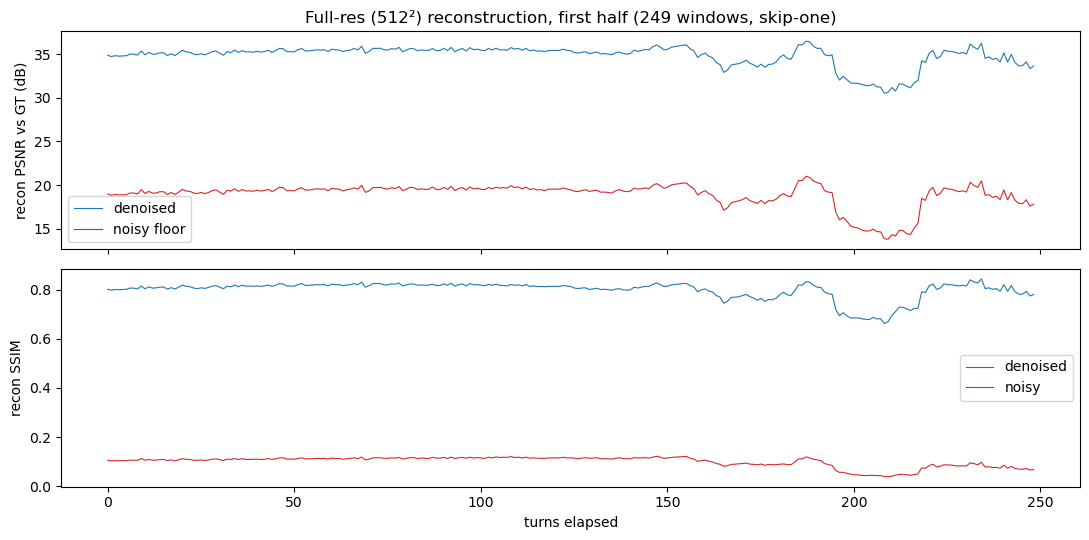

In [5]:
import json
fr=np.load(f'{CACHE}/recon_results_fullres_firsthalf.npz')
frs=json.load(open(f'{CACHE}/recon_summary_fullres_firsthalf.json'))
print(json.dumps(frs, indent=2))
fws=fr['window_starts']; fdp=fr['den_psnr']; fnp=fr['noisy_psnr']; fds=fr['den_ssim']; fns=fr['noisy_ssim']
turns_fr=(fws-fws[0])/PERIOD_360
print(f"\n512² denoised {fdp.mean():.2f} dB / SSIM {fds.mean():.3f}  |  noisy floor {fnp.mean():.2f} dB / {fns.mean():.3f}")
print(f"gain from denoising at full res: +{fdp.mean()-fnp.mean():.2f} dB / +{fds.mean()-fns.mean():.3f} SSIM")
fig,ax=plt.subplots(2,1,figsize=(11,5.5),sharex=True)
ax[0].plot(turns_fr,fdp,lw=0.8,label='denoised'); ax[0].plot(turns_fr,fnp,lw=0.8,color='C3',label='noisy floor')
ax[0].set_ylabel('recon PSNR vs GT (dB)'); ax[0].legend(); ax[0].set_title('Full-res (512²) reconstruction, first half (249 windows, skip-one)')
ax[1].plot(turns_fr,fds,lw=0.8,label='denoised'); ax[1].plot(turns_fr,fns,lw=0.8,color='C3',label='noisy'); ax[1].set_ylabel('recon SSIM'); ax[1].set_xlabel('turns elapsed'); ax[1].legend()
plt.tight_layout(); plt.show()

### 512² visual montage (early dynamic vs end-of-dynamic phase)

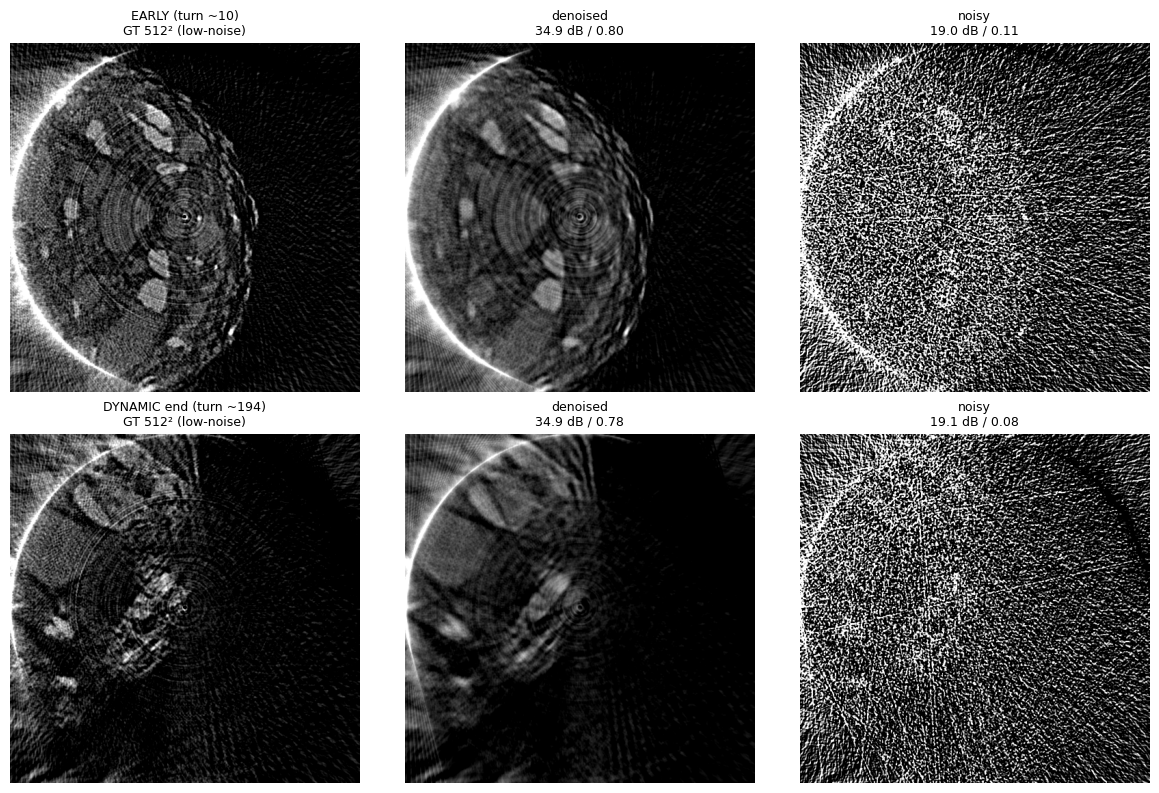

In [6]:
dev=torch.device('cuda'); win=R.window_length_frames(180.0)
mask512=R.make_mask(crop[1],crop[1]).to(dev)
def arms_fr(s):
    idx=np.arange(s,s+win); gt=R.native_window_gpu(src,idx,crop,R.ROT_AXIS_COL,dev)
    g=torch.Generator(device=dev).manual_seed(seed+s)
    cs={'GT':gt,'noisy':R.noisy_window_gpu(gt,dose,g),'denoised':R.denoised_window_gpu(den_mm,first,idx,dev)}
    return {a:R.reconstruct(R.counts_to_attenuation(cs[a],I0),R.projection_angles(idx),det_bin=1,method='fbp',device=dev) for a in R.ARMS}
fig,ax=plt.subplots(2,3,figsize=(12,8))
for r,(lbl,s) in enumerate([('EARLY (turn ~10)',first+2000),('DYNAMIC end (turn ~194)',439000)]):
    v=arms_fr(s); z=v['GT'].shape[0]//2; dr=float(v['GT'][...,mask512].max()-v['GT'][...,mask512].min())
    for c,a in enumerate(R.ARMS):
        ax[r,c].imshow(v[a][z].cpu().numpy(),cmap='gray',vmin=0,vmax=0.012); ax[r,c].axis('off')
        t=f'{lbl}\nGT 512² (low-noise)' if a=='GT' else f'{a}\n%.1f dB / %.2f'%R.masked_scores(v['GT'],v[a],mask512,dr)
        ax[r,c].set_title(t,fontsize=9)
plt.tight_layout(); plt.show()

### 512² movie (GT | denoised | noisy)

In [3]:
from IPython.display import Video, display
import os
p=f'{CACHE}/recon_sweep_fullres_firsthalf.mov'; mb=os.path.getsize(p)/1e6
print(f'{os.path.basename(p)}  ({mb:.1f} MB)  — GT | denoised | noisy, first half, skip-one')
display(Video(p, embed=(mb<8), width=820))

recon_sweep_fullres_firsthalf.mov  (64.7 MB)  — GT | denoised | noisy, first half, skip-one
